In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [9]:
""" 
GENERATE BY GEMINI 3 PRO (Prompt)
---
write function to make abstract circles dataset
it generate random [radius, x_center, y_center, border_width, background_color (255,255,255), border_color (255,255,255), circle_color (255,255,255) and draw n_samples of size (3, 512, 512)
"""

def generate_abstract_circles(n_samples, img_size=512):
    """
    Generates a dataset of abstract circles with randomized colors and properties.
    
    Returns:
        dataset: numpy array of shape (n_samples, 3, 512, 512) containing the images.
        labels: list of dictionaries containing the ground-truth parameters for each image.
    """
    # Initialize the dataset array with uint8 to save memory (standard for 0-255 RGB)
    dataset = np.zeros((n_samples, 3, img_size, img_size), dtype=np.uint8)
    
    # Storing the parameters is highly recommended if you are training an AutoEncoder,
    # as you might want to use them for disentanglement metrics or conditional generation later.
    labels = []

    for i in range(n_samples):
        # 1. Generate random colors (RGB, 0-255)
        # Using .tolist() so cv2 can easily read the color tuples
        bg_color = np.random.randint(0, 256, size=3).tolist()
        circle_color = np.random.randint(0, 256, size=3).tolist()
        border_color = np.random.randint(0, 256, size=3).tolist()
        
        # 2. Generate random geometry
        radius = np.random.randint(20, img_size // 2)
        x_center = np.random.randint(0, img_size)
        y_center = np.random.randint(0, img_size)
        border_width = np.random.randint(2, 25)
        
        # 3. Create the background canvas
        # cv2 works natively in (Height, Width, Channels)
        img = np.full((img_size, img_size, 3), bg_color, dtype=np.uint8)
        
        # 4. Draw the filled circle (-1 thickness fills the shape)
        cv2.circle(img, (x_center, y_center), radius, circle_color, -1)
        
        # 5. Draw the border
        cv2.circle(img, (x_center, y_center), radius, border_color, border_width)
        
        # 6. Convert from (H, W, C) to (C, H, W) to match your requested shape
        img_channels_first = np.transpose(img, (2, 0, 1))
        
        # Store in the main dataset array
        dataset[i] = img_channels_first
        
        # Record the ground truth
        labels.append({
            "radius": radius, 
            "x_center": x_center, 
            "y_center": y_center,
            "border_width": border_width, 
            "bg_color": bg_color, 
            "border_color": border_color, 
            "circle_color": circle_color
        })
        
    return dataset, labels

# --- Example Usage ---
# dataset, ground_truths = generate_abstract_circles(n_samples=1000)
# print(f"Dataset shape: {dataset.shape}") # Output: (1000, 3, 512, 512)

In [12]:
# Generate the dataset
dataset, ground_truths = generate_abstract_circles(n_samples=5)
print(f"Dataset shape: {dataset.shape}") # Output: (5, 3, 512, 512)

Dataset shape: (5, 3, 512, 512)


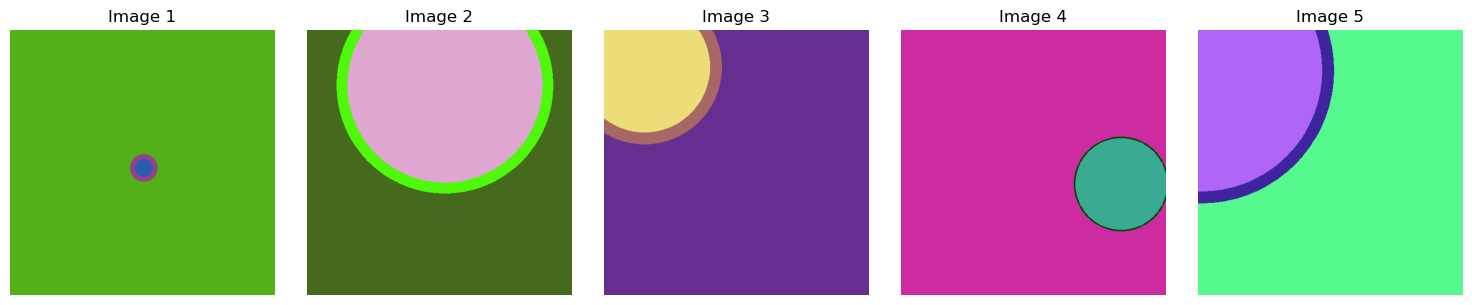

In [13]:
# using cursor: plot the dataet
# Plot the images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    # Channel-first (C, H, W) to channel-last (H, W, C) for plotting
    img = np.transpose(dataset[i], (1, 2, 0))
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Image {i+1}")
plt.tight_layout()
plt.show()

In [ ]:
# Using "Cursor" save images
from pathlib import Path
# Create datasets/circle folder if it doesn't exist
output_dir = Path("../images/circle")
output_dir.mkdir(parents=True, exist_ok=True)

# Save each image
for i, img_arr in enumerate(dataset):
    # Convert from (C, H, W) to (H, W, C)
    img = np.transpose(img_arr, (1, 2, 0))
    # Make sure image is uint8 (should be already from generation, but for safety)
    img = img.astype('uint8')
    img_path = output_dir / f"circle_{i}.png"
    cv2.imwrite(str(img_path), img)